In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [5]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [6]:
# This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# let me see if I can get the job done w/o this. 

class Pi(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))

    def forward(self, x):
        feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
        logit = feats @ self.theta
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [7]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

## 1. Two ways to weight the gradient

Both estimators below use the same per-step term $\nabla_\theta \log p_\theta(a_t|s_t)$; they differ only in the scalar it's multiplied by.

- **trajectory**: every step gets the episode's total return $R = \sum_t r_t$. This is Williams' episodic REINFORCE (1992, eq. 11): $\nabla J \approx R \, \nabla_\theta \log p_\theta(\tau)$.
- **reward_to_go**: step $t$ gets $G_t = \sum_{t' \ge t} r_{t'}$, the return still to come.

Same expected gradient; the second drops zero-mean terms (rewards earned before an action) and should be less noisy.

In [8]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n

In [9]:
def step_weights(rewards, weighting, gamma=1.0):
    """Scalar weight for each step's grad-log-prob term."""
    T = len(rewards)
    if weighting == 'trajectory':
        return torch.full((T,), float(sum(rewards)))          # whole-trajectory: R for every step
    elif weighting == 'reward_to_go':
        G = np.empty(T, dtype=np.float32); future = 0.0
        for t in reversed(range(T)):
            future = rewards[t] + gamma * future; G[t] = future
        return torch.tensor(G)                                  # G_t for step t
    raise ValueError(weighting)

In [10]:
def train(weighting, n_episodes=500, lr=0.00005, seed=52, theta_init=None):
    global pi                                                   # run_rollout reads the global pi
    torch.manual_seed(seed); np.random.seed(seed)
    pi = Pi()
    if theta_init is not None:
        with torch.no_grad(): pi.theta[:] = torch.tensor(theta_init)
    optimizer = optim.SGD(pi.parameters(), lr=lr)

    total_rewards, thetas = [], [pi.theta.detach().clone()]
    for epi in range(n_episodes):
        states, actions, rewards = run_rollout(seed=epi)
        T = len(rewards)
        weights = step_weights(rewards, weighting)
        # print(weights)

        state_batch  = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
        action_batch = torch.tensor(actions)                              # (T,)
        act_probs = pi(state_batch)[torch.arange(T), action_batch]        # prob of each action taken
        loss = -(torch.log(act_probs) * weights).sum()

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_rewards.append(sum(rewards)); thetas.append(pi.theta.detach().clone())
    return np.array(total_rewards), torch.stack(thetas).numpy()

## 2. Single run, whole-trajectory weighting

tensor([16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16., 16.,
        16., 16.])
tensor([38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38.,
        38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38.,
        38., 38., 38., 38., 38., 38., 38., 38., 38., 38.])
tensor([18., 18., 18., 18., 18., 18., 18., 18., 18., 18., 18., 18., 18., 18.,
        18., 18., 18., 18.])
tensor([44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44.,
        44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44.,
        44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44., 44.,
        44., 44.])
tensor([37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37.,
        37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37.,
        37., 37., 37., 37., 37., 37., 37., 37., 37.])
tensor([47., 47., 47., 47., 47., 47., 47., 47., 47., 47., 47., 47., 47., 47.,
        47., 47., 47., 47., 47., 47., 47

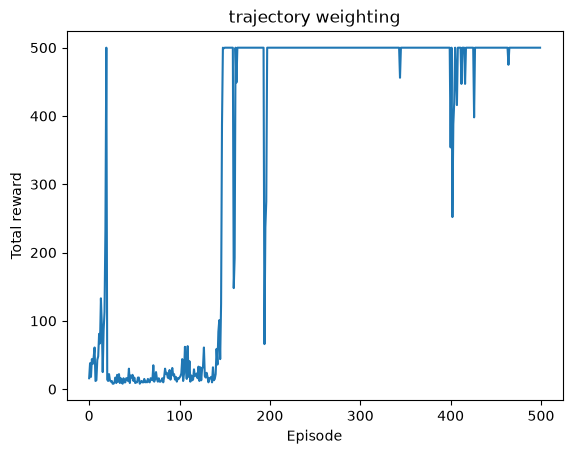

In [11]:
rewards_traj, thetas_traj = train('trajectory')
plt.plot(rewards_traj); plt.xlabel('Episode'); plt.ylabel('Total reward'); plt.title('trajectory weighting');

## 3. Head-to-head: same seeds, both weightings

In [12]:
N_EPISODES, SEEDS = 500, [52, 53, 54, 55]
runs = {w: [train(w, n_episodes=N_EPISODES, seed=s) for s in SEEDS] for w in ['trajectory', 'reward_to_go']}

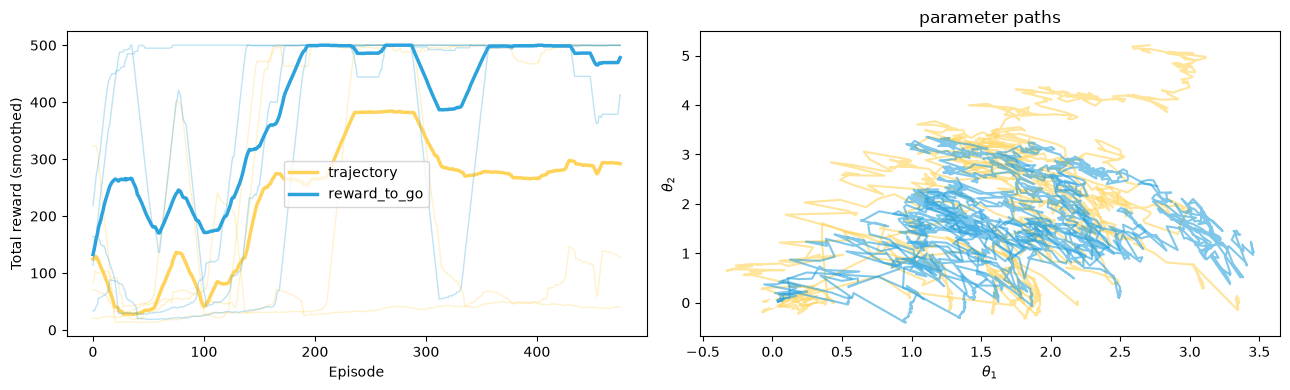

In [13]:
def smooth(x, k=25): return np.convolve(x, np.ones(k)/k, mode='valid')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
for w, color in [('trajectory', YELLOW), ('reward_to_go', BLUE)]:
    R = np.array([r for r, _ in runs[w]])                                     # (n_seeds, N_EPISODES)
    for r in R: axL.plot(smooth(r), color=color, alpha=0.3, lw=1)
    axL.plot(smooth(R.mean(0)), color=color, lw=2.5, label=w)
    for _, th in runs[w]: axR.plot(th[:, 0], th[:, 1], color=color, alpha=0.6, lw=1.5)
    axR.scatter(*runs[w][0][1][0], color='w', s=30, zorder=5)
axL.set_xlabel('Episode'); axL.set_ylabel('Total reward (smoothed)'); axL.legend()
axR.set_xlabel(r'$\theta_1$'); axR.set_ylabel(r'$\theta_2$'); axR.set_title('parameter paths')
plt.tight_layout()

In [14]:
for w in runs:
    R = np.array([r for r, _ in runs[w]])
    print(f'{w:13s}  mean reward over last 100 episodes: {R[:, -100:].mean():6.1f}  (per seed: {np.round(R[:, -100:].mean(1), 1)})')

trajectory     mean reward over last 100 episodes:  282.1  (per seed: [490.6  42.6 500.   95. ])
reward_to_go   mean reward over last 100 episodes:  488.4  (per seed: [498.6 499.3 499.8 456. ])


## Notes
- The trajectory-weighted gradient is roughly 2x the reward-to-go one for the same episode (weights sum to $T^2$ vs $\approx T^2/2$), so the same `lr` is a fair-ish comparison, but you may want to sweep it.
- If trajectory weighting looks noticeably noisier or slower, that's the effect Williams flagged: credit and blame get spread uniformly over all past steps.
- To start from the chapter's $\theta_0$ instead of zeros, pass `theta_init=[-0.5, 0.0]` to `train`.